# Exploring the Dynamics of the Habit-Portfolio Model

The consumption-saving model with portfolio choice and habit formation is fairly novel, and thus the role of habit formation is not well understood. This notebook presents some exercises that explore how model outcomes evolve in response to an unexpected shock, using an infinite horizon framework.

In [1]:
from HARK.models import HabitPortfolioConsumerType, RiskyAssetConsumerType
from HARK.ConsumptionSaving.ConsHabitPortfolioModel import (
    HabitPortfolioConsumerType_defaults,
)
from time import time
import numpy as np
import matplotlib.pyplot as plt

mystr = lambda x: "{:.3f}".format(x)

First, we'll define a base parameter dictionary, as well as some functions we'll use to run and plot the experiments.

In [2]:
# Make a parameter dictionary
my_params = HabitPortfolioConsumerType_defaults.copy()
del my_params["constructors"]  # don't want to overwrite these
my_params["CRRA"] = 6.0
my_params["Rfree"] = [1.01]
my_params["RiskyAvg"] = 1.04
my_params["RiskyStd"] = 0.18
my_params["RiskyShareFixed"] = None
my_params["HabitRte"] = 0.1
my_params["hLogInitMean"] = 0.0
my_params["cycles"] = 0
my_params["T_sim"] = 700

T_burn = 500

In [3]:
# Define a function that runs an MIT shock experiment
def run_MIT_shock_experiment(Agent, var, factor, T_shock):
    # Execute the MIT shock experiment
    Agent.initialize_sym()
    Agent.symulate(T_shock)
    if var in Agent._simulator.data:
        Agent._simulator.data[var] *= factor
    Agent.symulate()

    # Extract average sequences of assets, consumption, risky asset share, and habits
    C = np.mean(Agent.hystory["cNrm"], axis=1)
    A = np.mean(Agent.hystory["aNrm"], axis=1)
    S = np.mean(Agent.hystory["Share"], axis=1)
    if "hNrm" in Agent.hystory:
        H = np.mean(Agent.hystory["hNrm"], axis=1)
    else:
        H = np.ones_like(C)

    return C, A, S, H

In [4]:
# Define a function to run an experiment on several types and return lists
def run_experiment_on_types(Agents, var, factor, T_shock):
    C_out = []
    A_out = []
    S_out = []
    H_out = []
    for Agent in Agents:
        C, A, S, H = run_MIT_shock_experiment(Agent, var, factor, T_shock)
        C_out.append(C)
        A_out.append(A)
        S_out.append(S)
        H_out.append(H)
    return C_out, A_out, S_out, H_out

In [5]:
# Define a function to compare the results of experiments across types
def make_experiment_comparison_plot(X, T0, outcome, labels):
    t_vec = np.arange(-20, len(X[0]) - T0)
    for j in range(len(X)):
        plt.plot(t_vec, X[j][(T0 - 20) :], "-")
    plt.xlabel(r"time $t$")
    plt.ylabel(outcome)
    plt.legend(labels, loc=(0.05, -0.2), ncols=4)
    plt.tight_layout()
    plt.show()

In [6]:
# Define a function to draw four comparison plots
def draw_four_plots(CASH, T0, labels):
    make_experiment_comparison_plot(CASH[0], T0, r"Consumption $c_t$", labels)
    make_experiment_comparison_plot(CASH[1], T0, r"End-of-period assets $a_t$", labels)
    make_experiment_comparison_plot(CASH[2], T0, r"Risky asset share $s_t$", labels)
    make_experiment_comparison_plot(CASH[3], T0, r"Habit stock $h_t$", labels)

In [7]:
# Make and solve the base type with no habits
BaseType = RiskyAssetConsumerType(**my_params)
t0 = time()
BaseType.solve()
t1 = time()
print("Solving the model with no habits took " + mystr(t1 - t0) + " seconds.")

Solving the model with no habits took 4.491 seconds.


First, let's experiment with what the "habit weight" parameter $\alpha$ does, using low, medium, and high values.

In [8]:
# Make and solve agents with low, medium, and high habits
alpha_list = [0.2, 0.5, 0.8]
HabitTypes = []
for j in range(len(alpha_list)):
    t0 = time()
    temp_params = my_params.copy()
    temp_params["HabitWgt"] = alpha_list[j]
    HabitTypes.append(HabitPortfolioConsumerType(**temp_params))
    HabitTypes[-1].solve()
    t1 = time()
    print(
        "Solving the habit type with alpha="
        + mystr(alpha_list[j])
        + " took "
        + mystr(t1 - t0)
        + " seconds."
    )

Solving the habit type with alpha=0.200 took 284.668 seconds.
Solving the habit type with alpha=0.500 took 192.602 seconds.
Solving the habit type with alpha=0.800 took 150.708 seconds.


In [9]:
# Define type labels
my_agents = [BaseType] + HabitTypes
type_labels = [r"$\alpha=0$"]
for j in range(len(alpha_list)):
    type_labels.append(r"$\alpha$=" + str(alpha_list[j]))

In [10]:
# Run an experiment in which wealth is shocked downward by 50%
t0 = time()
CASH_neg_wealth = run_experiment_on_types(my_agents, "aNrm", 0.5, T_burn)
t1 = time()
print("The negative wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative wealth shock experiment took 46.237 seconds.


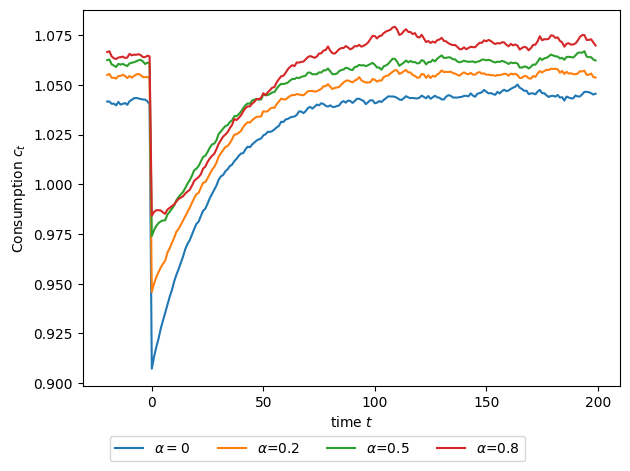

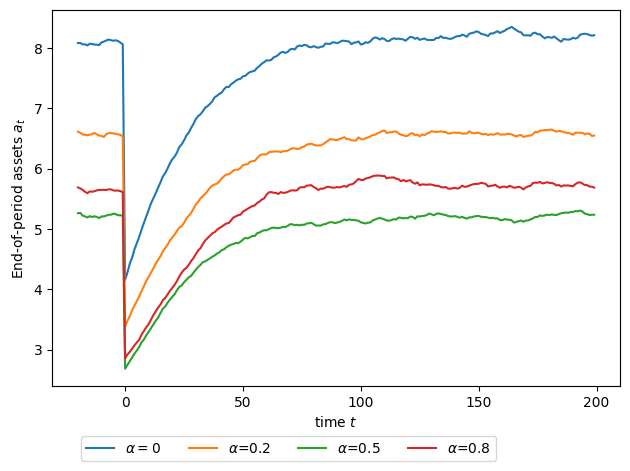

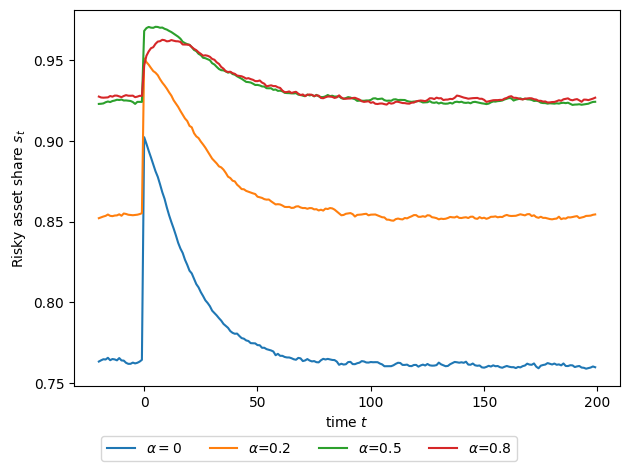

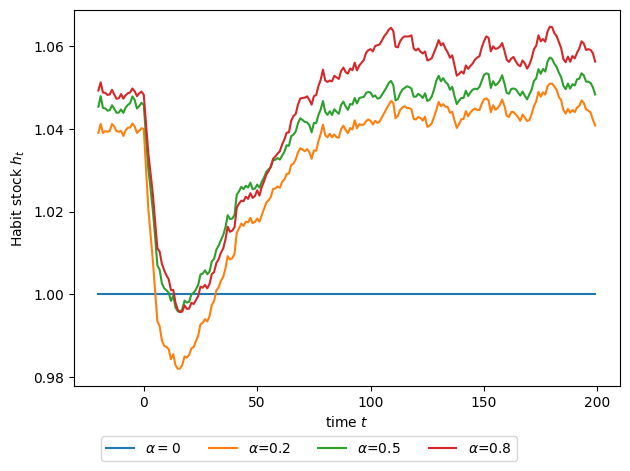

In [11]:
# Plot the results of the negative wealth shock experiment
draw_four_plots(CASH_neg_wealth, T_burn, type_labels)

In [12]:
# Run an experiment in which wealth is shocked upward by 50%
t0 = time()
CASH_pos_wealth = run_experiment_on_types(my_agents, "aNrm", 1.5, T_burn)
t1 = time()
print("The positive wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive wealth shock experiment took 46.536 seconds.


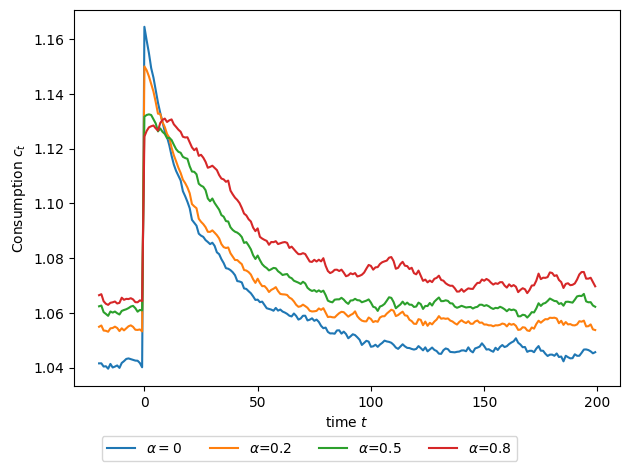

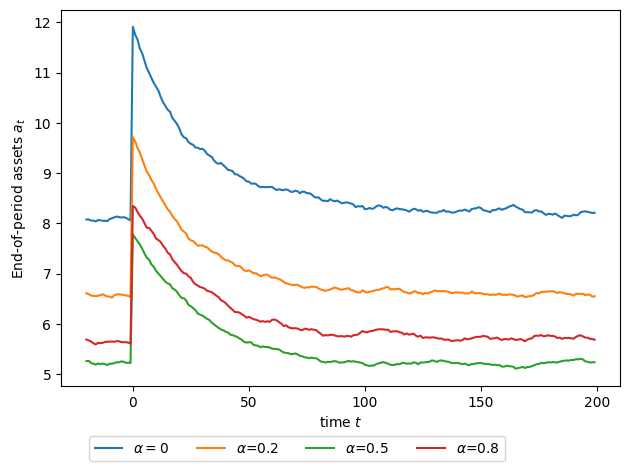

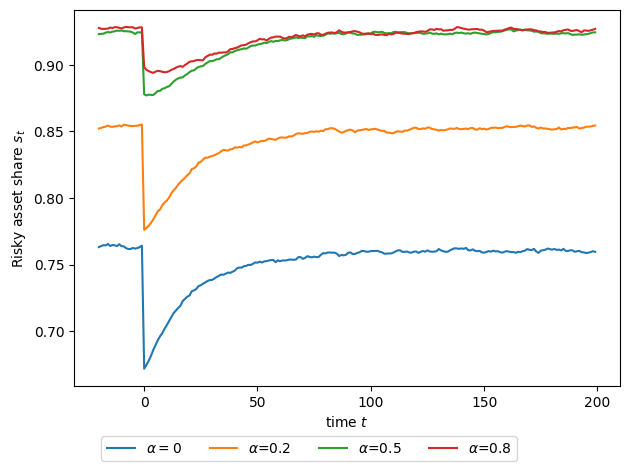

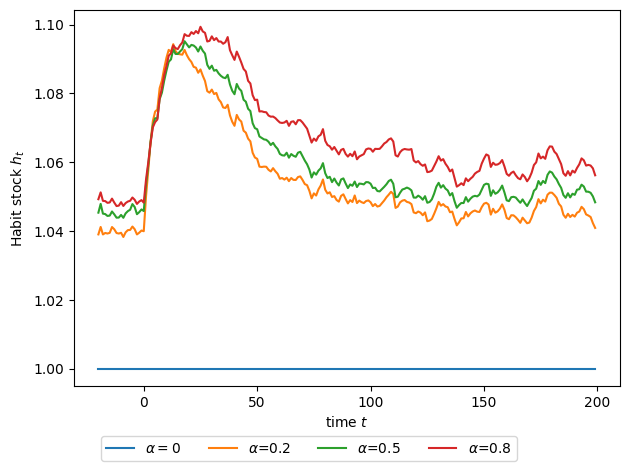

In [13]:
# Plot the results of the positive wealth shock experiment
draw_four_plots(CASH_pos_wealth, T_burn, type_labels)

In [14]:
# Run an experiment in which the habit stock is shocked downward by 50%
t0 = time()
CASH_neg_habit = run_experiment_on_types(my_agents, "HNrm", 0.5, T_burn)
t1 = time()
print("The negative habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative habit shock experiment took 46.664 seconds.


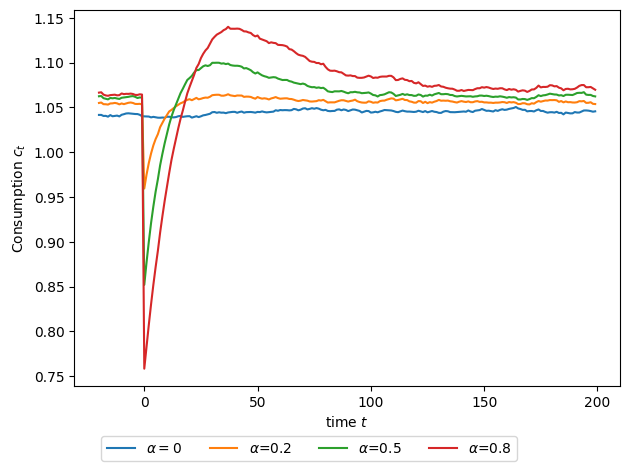

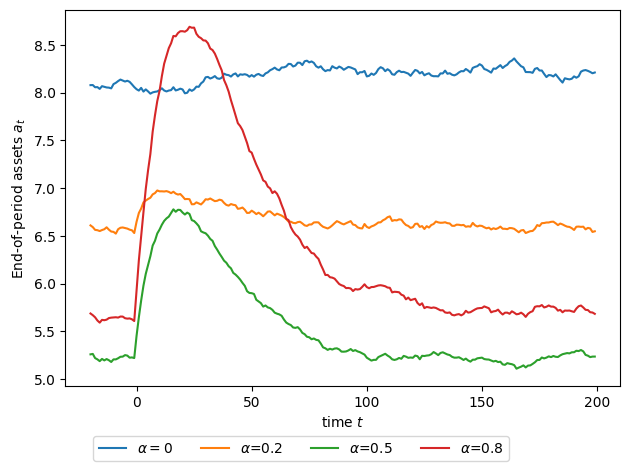

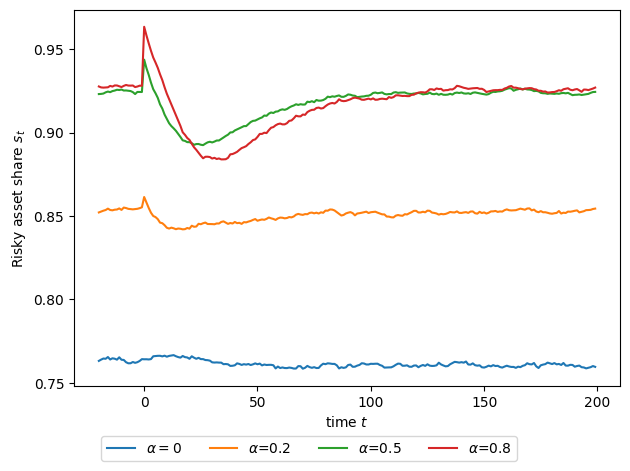

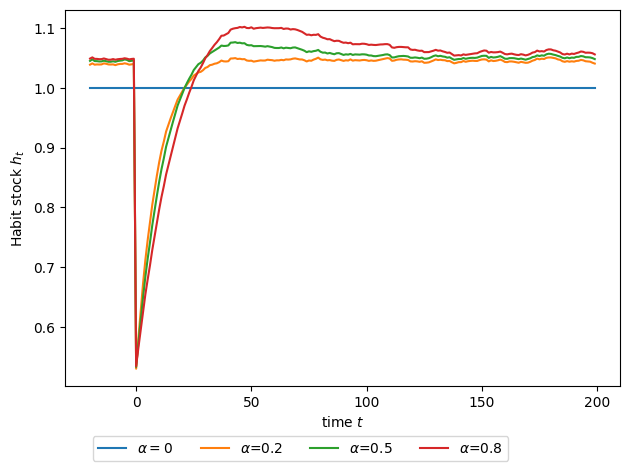

In [15]:
# Plot the results of the negative habit shock experiment
draw_four_plots(CASH_neg_habit, T_burn, type_labels)

In [16]:
# Run an experiment in which the habit stock is shocked upward by 50%
t0 = time()
CASH_pos_habit = run_experiment_on_types(my_agents, "HNrm", 1.5, T_burn)
t1 = time()
print("The positive habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive habit shock experiment took 46.467 seconds.


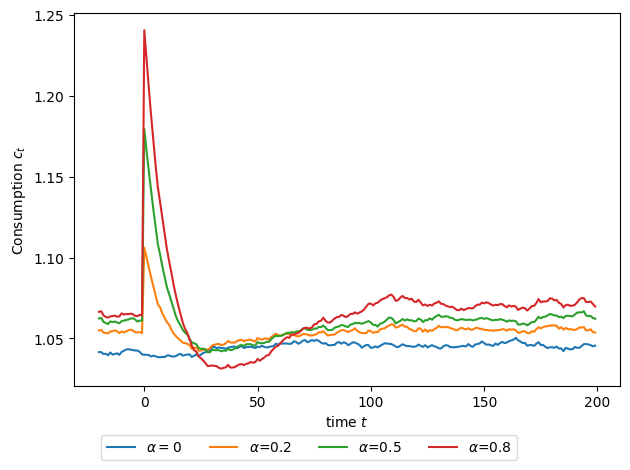

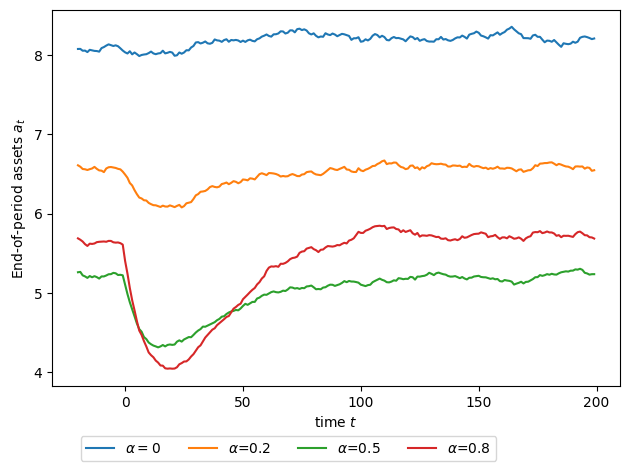

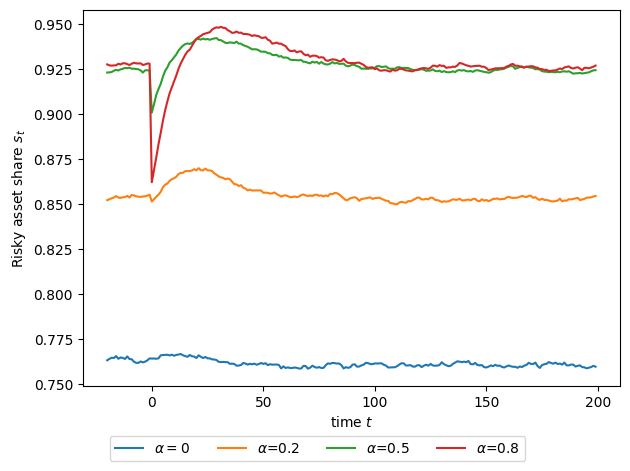

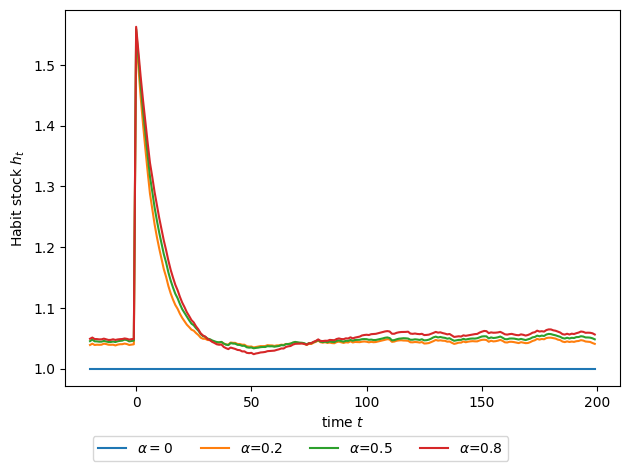

In [17]:
# Plot the results of the positive habit shock experiment
draw_four_plots(CASH_pos_habit, T_burn, type_labels)

Now let's experiment with the "habit rate" parameter $\lambda$. We'll use the "strong habits" type ($\alpha = 0.8$) as the base. At the top of this notebook, we set $\lambda = 0.1$ for the prior experiment, which is a fairly slow rate of habit updating. Let's try two faster rates and run the same experiments as before.

In [20]:
# Make and solve agents with habits that evolve faster
lambda_list = [0.2, 0.3]
HabitTypesAlt = []
for j in range(len(lambda_list)):
    t0 = time()
    temp_params = my_params.copy()
    temp_params["HabitWgt"] = alpha_list[-1]  # use strongest habit
    temp_params["HabitRte"] = lambda_list[j]
    HabitTypesAlt.append(HabitPortfolioConsumerType(**temp_params))
    HabitTypesAlt[-1].solve()
    t1 = time()
    print(
        "Solving the habit type with lambda="
        + mystr(lambda_list[j])
        + " took "
        + mystr(t1 - t0)
        + " seconds."
    )

Solving the habit type with lambda=0.200 took 127.642 seconds.
Solving the habit type with lambda=0.300 took 2.939 seconds.


It looks like the $\lambda = 0.3$ type broke the solver, so you shouldn't trust those results. We are still working on making the solver produce stable results for any parameter values.

In [21]:
# Define type labels
my_agents_alt = [HabitTypes[-1]] + HabitTypesAlt
type_labels_alt = [r"$\lambda=0.1$"]
for j in range(len(lambda_list)):
    type_labels_alt.append(r"$\lambda$=" + str(lambda_list[j]))

In [22]:
# Run an experiment in which wealth is shocked downward by 50%
t0 = time()
CASH_neg_wealth_alt = run_experiment_on_types(my_agents_alt, "aNrm", 0.5, T_burn)
t1 = time()
print("The negative wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative wealth shock experiment took 39.067 seconds.


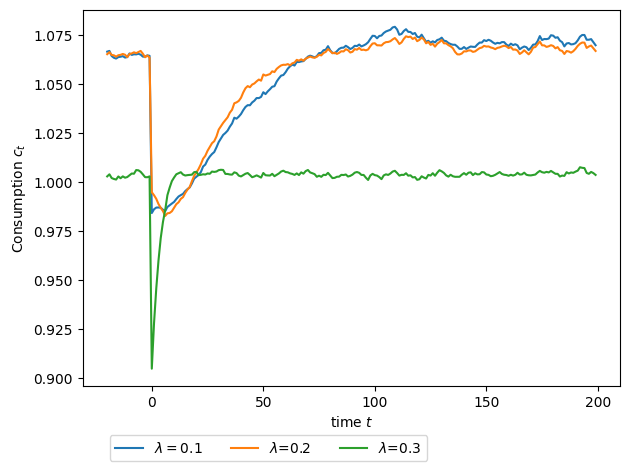

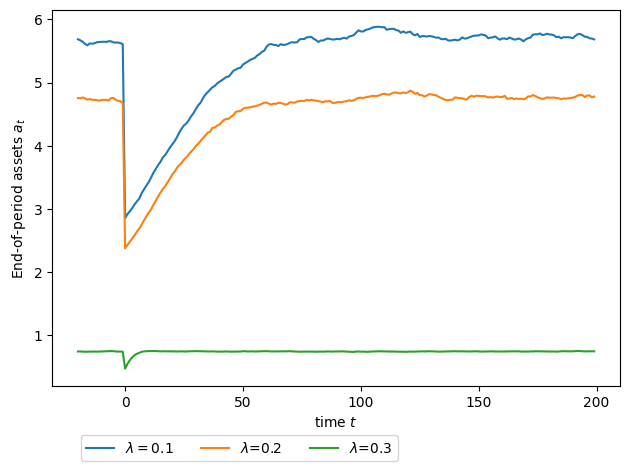

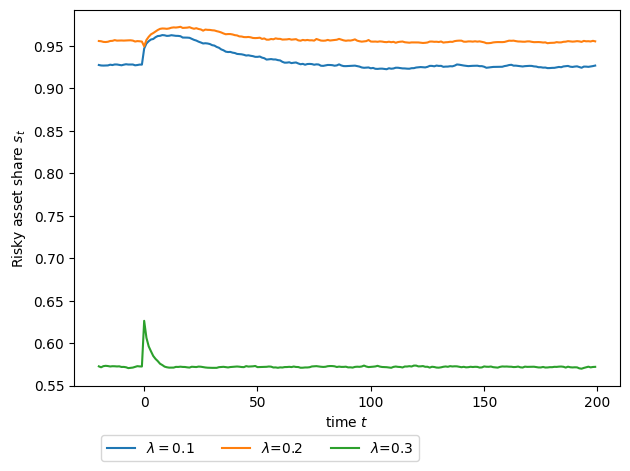

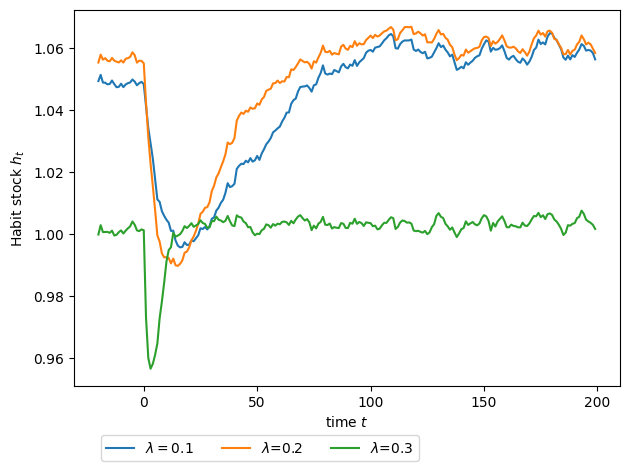

In [23]:
# Plot the results of the negative wealth shock experiment
draw_four_plots(CASH_neg_wealth_alt, T_burn, type_labels_alt)

In [24]:
# Run an experiment in which wealth is shocked upward by 50%
t0 = time()
CASH_pos_wealth_alt = run_experiment_on_types(my_agents_alt, "aNrm", 1.5, T_burn)
t1 = time()
print("The positive wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive wealth shock experiment took 39.481 seconds.


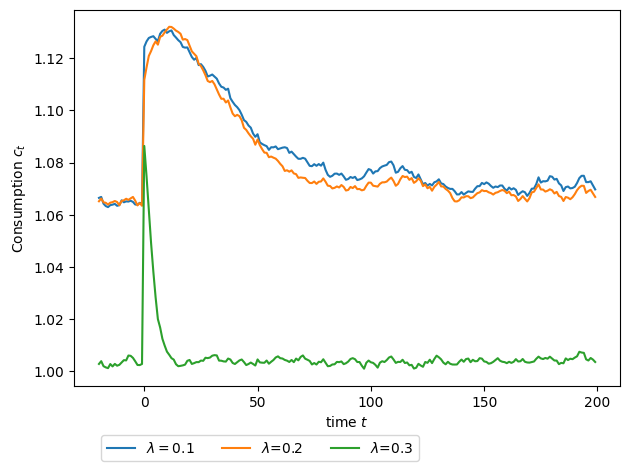

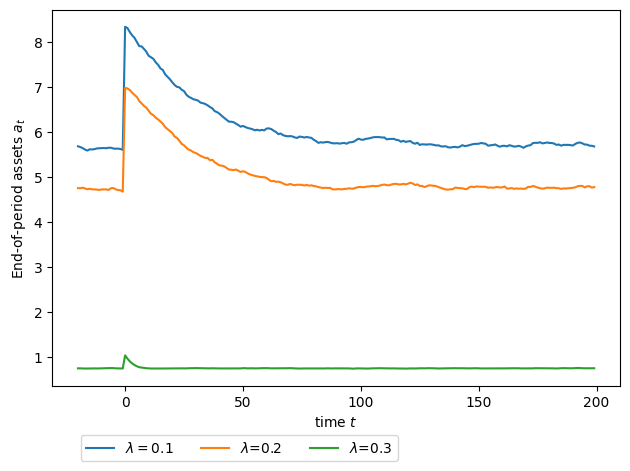

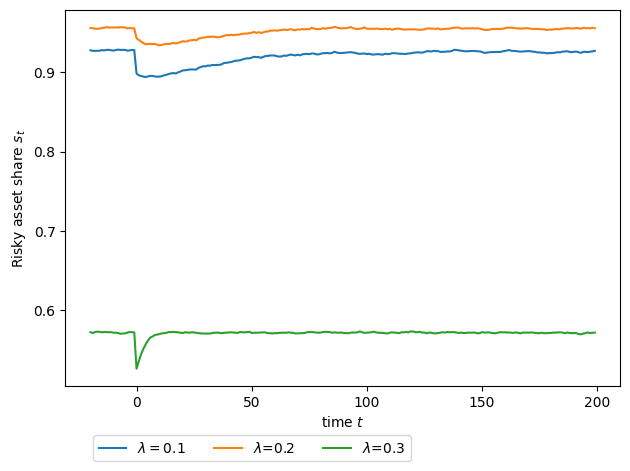

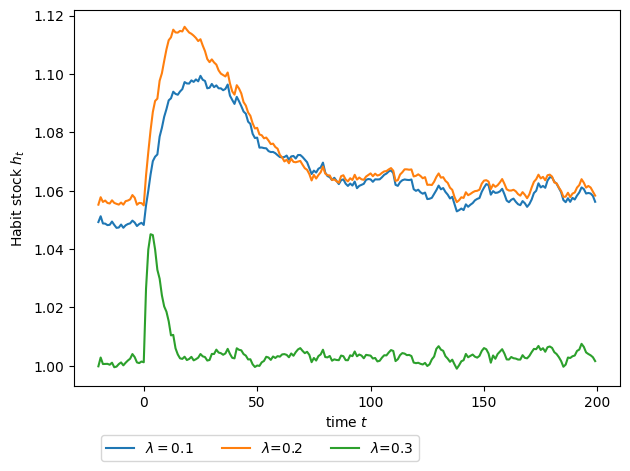

In [30]:
# Plot the results of the positive wealth shock experiment
draw_four_plots(CASH_pos_wealth_alt, T_burn, type_labels_alt)

In [26]:
# Run an experiment in which the habit stock is shocked downward by 50%
t0 = time()
CASH_neg_habit_alt = run_experiment_on_types(my_agents_alt, "HNrm", 0.5, T_burn)
t1 = time()
print("The negative habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative habit shock experiment took 40.090 seconds.


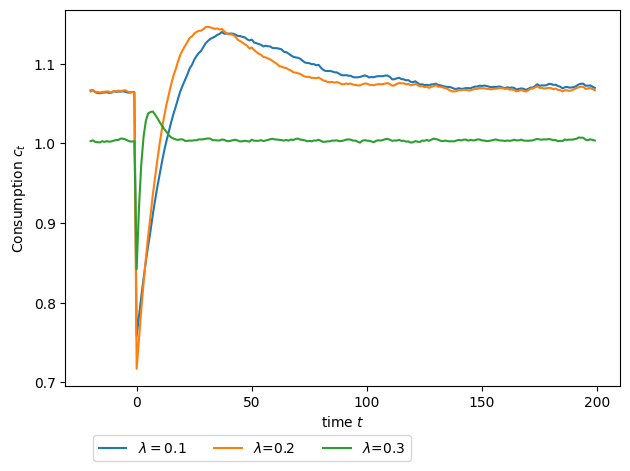

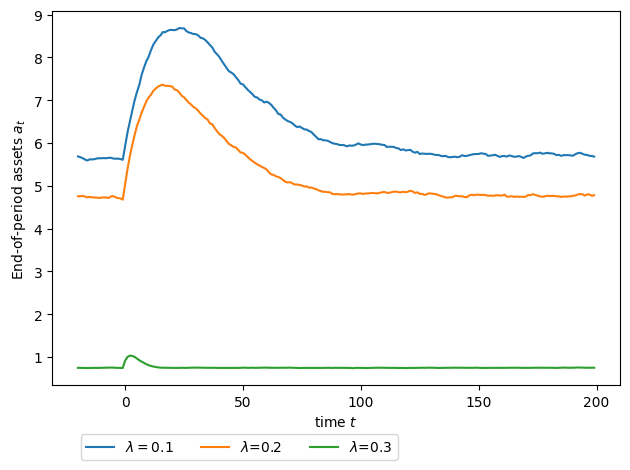

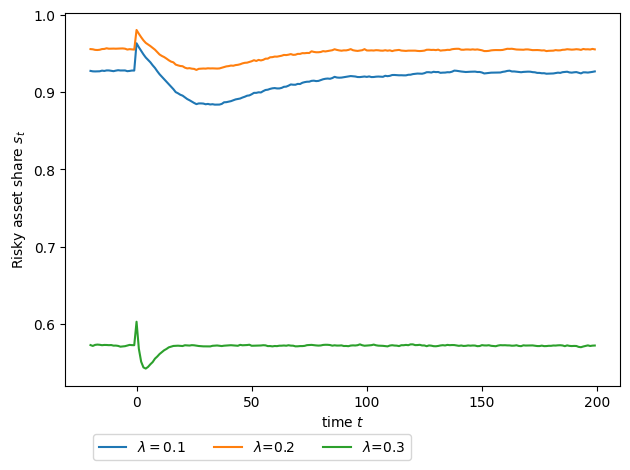

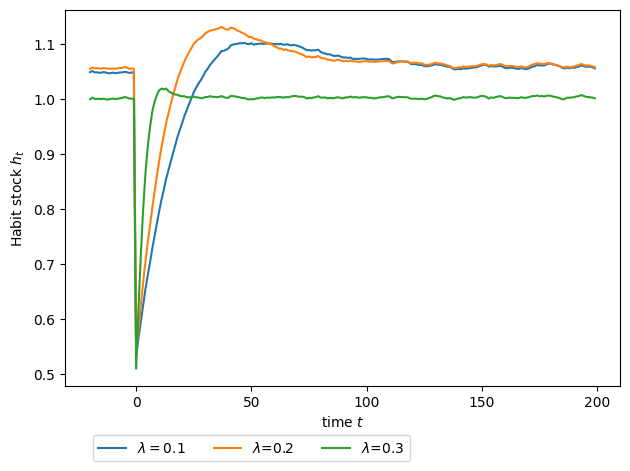

In [31]:
# Plot the results of the negative habit shock experiment
draw_four_plots(CASH_neg_habit_alt, T_burn, type_labels_alt)

In [28]:
# Run an experiment in which the habit stock is shocked upward by 50%
t0 = time()
CASH_pos_habit_alt = run_experiment_on_types(my_agents_alt, "HNrm", 1.5, T_burn)
t1 = time()
print("The positive habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive habit shock experiment took 40.568 seconds.


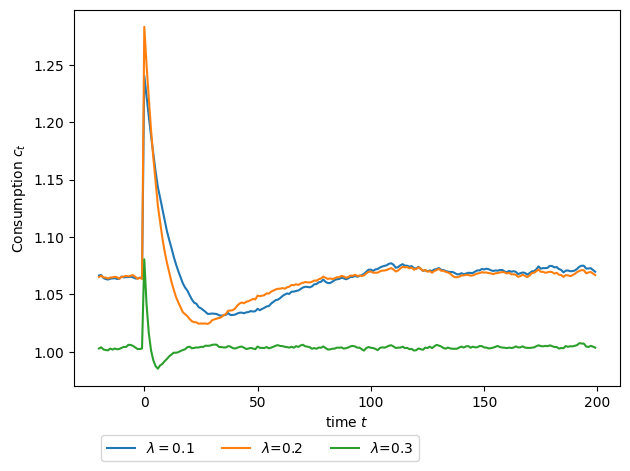

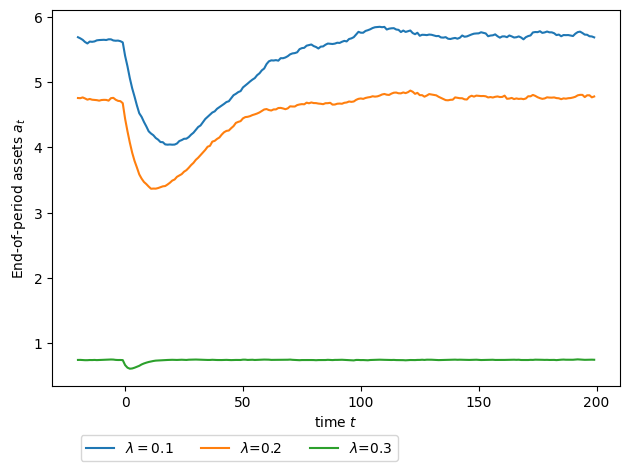

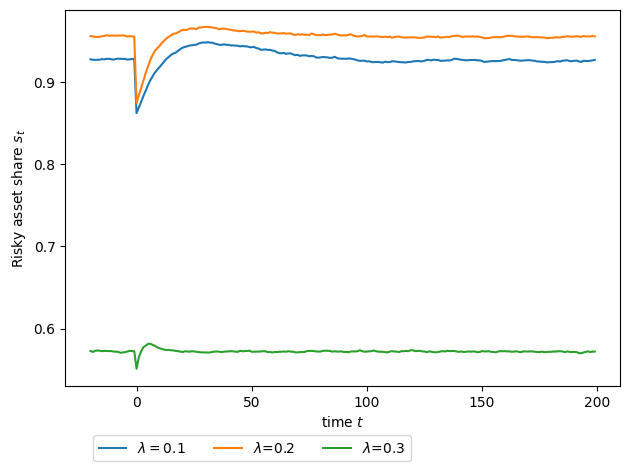

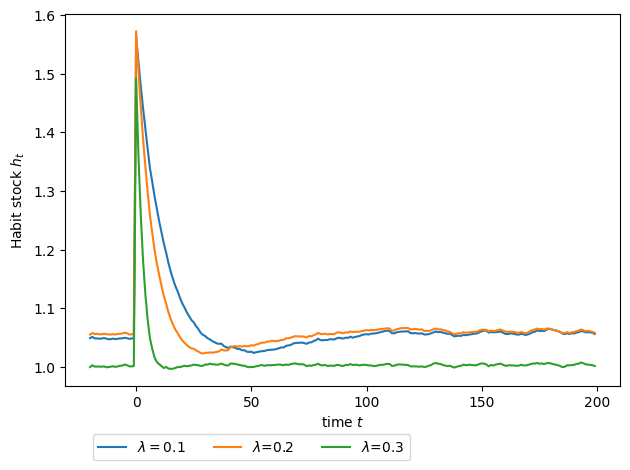

In [32]:
# Plot the results of the positive habit shock experiment
draw_four_plots(CASH_pos_habit_alt, T_burn, type_labels_alt)